Data Extraction

In [13]:
import yfinance as yf
import pandas as pd
import os

tickers = ["TSLA", "BND", "SPY"]

raw = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-01-15",
    group_by="ticker",
    auto_adjust=False
)

frames = []

for ticker in tickers:
    temp = raw[ticker].copy()
    temp.reset_index(inplace=True)
    temp["Ticker"] = ticker
    frames.append(temp)

final_df = pd.concat(frames, ignore_index=True)

# Save generated raw data
os.makedirs("data/raw", exist_ok=True)
final_df.to_csv("data/raw/prices.csv", index=False)

final_df.head()



[*********************100%***********************]  3 of 3 completed


Price,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000,TSLA
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500,TSLA
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500,TSLA
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000,TSLA
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500,TSLA


EDA – Price Trends

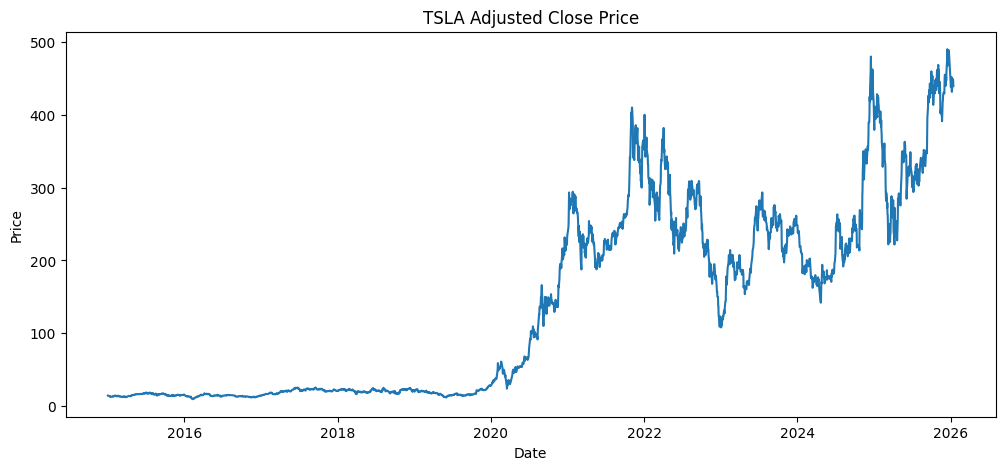

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

tsla = final_df[final_df["Ticker"] == "TSLA"]
plt.figure(figsize=(12,5))
plt.plot(tsla["Date"], tsla["Adj Close"])
plt.title("TSLA Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


Daily Returns & Volatility

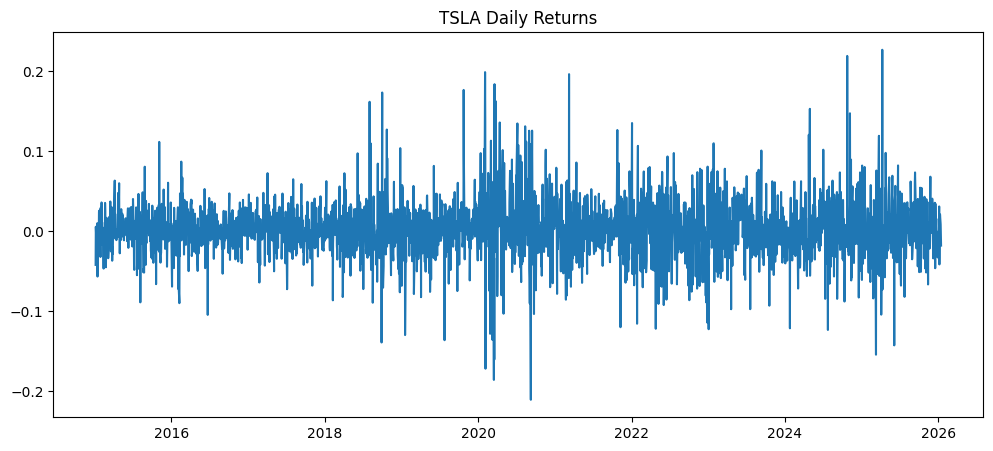

In [22]:
# %pip install -e .

# import sys
# from pathlib import Path
# sys.path.insert(0, str(Path.cwd()))

# from src.preprocessing import compute_returns

# Compute daily returns for TSLA using pandas directly
tsla_returns = tsla["Adj Close"].pct_change().dropna()

plt.figure(figsize=(12,5))
plt.plot(tsla["Date"][1:], tsla_returns)
plt.title("TSLA Daily Returns")
plt.show()


Rolling Volatility

/tmp/ipykernel_27780/243669004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsla["Rolling_Vol"] = tsla["Adj Close"].pct_change().rolling(30).std()


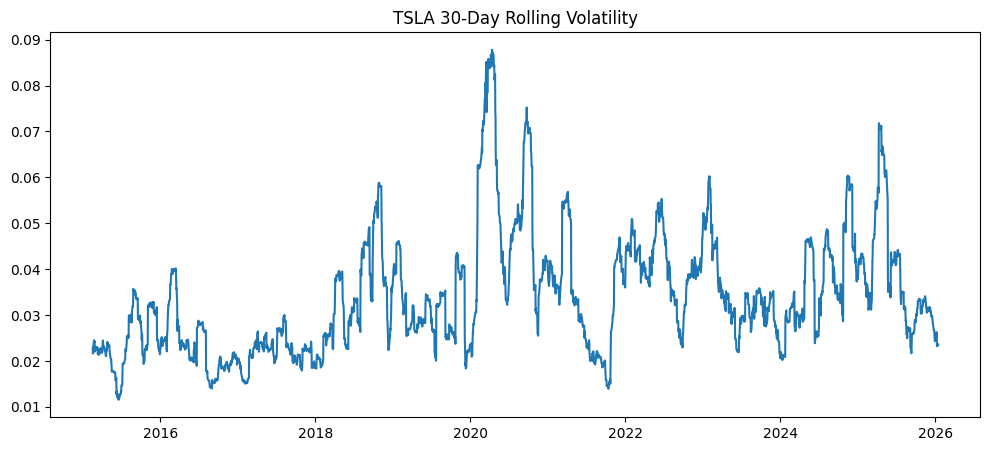

In [23]:
tsla["Rolling_Vol"] = tsla["Adj Close"].pct_change().rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(tsla["Date"], tsla["Rolling_Vol"])
plt.title("TSLA 30-Day Rolling Volatility")
plt.show()


Stationarity Test (ADF)

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(tsla["Adj Close"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -0.7801569882105674
p-value: 0.8248814297221101


Risk Metrics

In [25]:
import numpy as np

returns = tsla["Adj Close"].pct_change().dropna()

VaR_95 = np.percentile(returns, 5)
sharpe = returns.mean() / returns.std() * np.sqrt(252)

print("VaR (95%):", VaR_95)
print("Sharpe Ratio:", sharpe)


VaR (95%): -0.05252946182633338
Sharpe Ratio: 0.8231849992036502
